# Stage 15 — Embedding index over REMIT

This notebook is the demo surface for the Stage 15 embeddings layer
``bristol_ml.embeddings``. It answers one question with one
side-by-side view: **for a given REMIT event, which other events are
semantically nearest, and how does that look on a 2D projection?**

The demo moment (intent §"Demo moment") is the top-k printout plus
the UMAP scatter — a facilitator picks "planned nuclear outage" as
the query, the notebook returns ten neighbours sorted by cosine
score, and a 2D projection shows the cluster structure visually.

The mechanic that makes the demo runnable in any environment — with
or without the live ``Alibaba-NLP/gte-modernbert-base`` checkpoint
warm in the local HF cache — is the stub-first triple gate plus the
content-hash cache:

- ``BRISTOL_ML_EMBEDDING_STUB=1`` forces the offline stub path
  (default in CI / notebooks).
- The cache invalidates on corpus SHA-256 *or* model_id change, so
  flipping between stub and live with the same corpus rebuilds
  cleanly.

- **Intent:** `docs/intent/15-embedding-index.md`.
- **Plan:** `docs/plans/completed/15-embedding-index.md`.
- **Module:** `src/bristol_ml/embeddings/`.

CI runs this notebook against an 8-row REMIT fixture under
``BRISTOL_ML_EMBEDDING_STUB=1`` (deterministic, offline). The cells
are also valid in live mode: set the env var to ``0`` after running
the documented HF-cache pre-warm one-liner from
``README.md`` and re-execute.


In [1]:
# T5 Cell 1 — Bootstrap, locate the repo root, load embedding config.
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

# Force-stub independent of the YAML default — the notebook MUST
# execute under offline CI without the gte-modernbert model warm in
# the local HF cache.  Set this BEFORE importing any embeddings code.
os.environ["BRISTOL_ML_EMBEDDING_STUB"] = "1"

import pandas as pd  # noqa: E402

from bristol_ml import load_config  # noqa: E402

# Compose the +embedding=default group; conf/config.yaml does not
# include it in defaults (mirrors Stage 12 ServingConfig + Stage 14
# LlmExtractorConfig).  The notebook always wants the embedding slot
# populated.
cfg = load_config(config_path=REPO_ROOT / "conf", overrides=["+embedding=default"])
assert cfg.embedding is not None, "embedding config not resolved"
print(f"embedding.type:            {cfg.embedding.type}")
print(f"embedding.model_id:        {cfg.embedding.model_id}")
print(f"embedding.vector_backend:  {cfg.embedding.vector_backend}")
print(f"embedding.cache_path:      {cfg.embedding.cache_path}")
print(f"embedding.projection_type: {cfg.embedding.projection_type}")
print(f"embedding.fp16:            {cfg.embedding.fp16}")
print(f"BRISTOL_ML_EMBEDDING_STUB: {os.environ['BRISTOL_ML_EMBEDDING_STUB']}")

embedding.type:            stub
embedding.model_id:        Alibaba-NLP/gte-modernbert-base
embedding.vector_backend:  numpy
embedding.cache_path:      None
embedding.projection_type: umap
embedding.fp16:            True
BRISTOL_ML_EMBEDDING_STUB: 1


In [2]:
# T5 Cell 2 — Load the tiny REMIT fixture; print size + NULL-message ratio.
CORPUS_PATH = REPO_ROOT / "tests" / "fixtures" / "embedding" / "tiny_corpus.parquet"
assert CORPUS_PATH.exists(), (
    f"Expected fixture at {CORPUS_PATH}; rebuild with "
    "`uv run python scripts/_build_embedding_fixture.py`."
)

corpus = pd.read_parquet(CORPUS_PATH)
print(f"corpus path: {CORPUS_PATH}")
print(f"rows:        {len(corpus)}")
null_count = int(corpus["message_description"].isna().sum())
print(
    f"NULL message_description rows: {null_count} of {len(corpus)} ({null_count / len(corpus):.0%})"
)

print()
print("Per-fuel-type breakdown:")
print(corpus["fuel_type"].value_counts().to_string())

corpus path: /workspace/tests/fixtures/embedding/tiny_corpus.parquet
rows:        8
NULL message_description rows: 3 of 8 (38%)

Per-fuel-type breakdown:
fuel_type
Nuclear    2
Gas        2
Coal       2
Wind       2


In [3]:
# T5 Cell 3 — Embed the corpus; load-or-build the cache; report provenance.
import tempfile

from bristol_ml.embeddings._factory import build_embedder, embed_corpus

# Notebook always builds into a per-run tempdir: the demo is meant to
# be repeatable from a clean slate, so a stale cache from a prior
# laptop session does not silently survive into the new run.  In
# production callers (Stage 16 / RAG) the cache_path comes from the
# YAML and persists across runs as designed.
#
# ``TemporaryDirectory`` (over ``mkdtemp``) registers a finalizer so
# the directory is removed when the kernel shuts down — repeated
# notebook runs do not accumulate ``stage15_embedding_cache_*`` dirs
# under ``/tmp`` (Phase-3 code review CR-7).
_cache_tempdir = tempfile.TemporaryDirectory(prefix="stage15_embedding_cache_")
cache_dir = Path(_cache_tempdir.name)
embed_cfg = cfg.embedding.model_copy(update={"cache_path": cache_dir / "cache.parquet"})

# embed_corpus returns (VectorIndex, EmbeddingCache).  The cache
# carries the provenance (corpus_sha256, model_id, embedded_at_utc);
# the index carries the vectors hydrated for nearest-neighbour query.
index, cache = embed_corpus(
    config=embed_cfg,
    corpus=corpus,
    id_columns=("mrid", "revision_number"),
)
embedder = build_embedder(embed_cfg)  # for the query path in Cell 4

print(f"vectors shape:    {cache.vectors.shape}")
print(f"index dim:        {index.dim}")
print(f"corpus_sha256:    {cache.metadata.corpus_sha256_prefix}…")
print(f"model_id:         {cache.metadata.model_id}")
print(f"embedded_at_utc:  {cache.metadata.embedded_at_utc.isoformat()}")
print(f"cache_path:       {embed_cfg.cache_path}")

2026-04-28 00:07:41.017 | INFO     | bristol_ml.embeddings._factory:build_embedder:90 - build_embedder: BRISTOL_ML_EMBEDDING_STUB=1 — returning StubEmbedder (overrides YAML type='stub').


2026-04-28 00:07:41.018 | DEBUG    | bristol_ml.embeddings._embedder:__init__:141 - StubEmbedder constructed (dim=8, model_id=stub-sha256-8)


2026-04-28 00:07:41.020 | INFO     | bristol_ml.embeddings._cache:write:242 - EmbeddingCache written to /tmp/stage15_embedding_cache_4wassl_i/cache.parquet (n=8, dim=8, model_id=stub-sha256-8, corpus_sha256=be4982248271)


2026-04-28 00:07:41.021 | INFO     | bristol_ml.embeddings._factory:embed_corpus:267 - embed_corpus: index hydrated (n=8, dim=8, backend=numpy).


2026-04-28 00:07:41.021 | INFO     | bristol_ml.embeddings._factory:build_embedder:90 - build_embedder: BRISTOL_ML_EMBEDDING_STUB=1 — returning StubEmbedder (overrides YAML type='stub').


2026-04-28 00:07:41.021 | DEBUG    | bristol_ml.embeddings._embedder:__init__:141 - StubEmbedder constructed (dim=8, model_id=stub-sha256-8)


vectors shape:    (8, 8)
index dim:        8
corpus_sha256:    be4982248271…
model_id:         stub-sha256-8
embedded_at_utc:  2026-04-28T00:07:41.019754+00:00
cache_path:       /tmp/stage15_embedding_cache_4wassl_i/cache.parquet


In [4]:
# T5 Cell 4 — Fixed query → ten nearest neighbours with cosine scores.
QUERY_TEXT = "planned nuclear outage"
TOP_K = min(cfg.embedding.default_top_k, len(corpus))

query_vec = embedder.embed(QUERY_TEXT)
neighbours = index.query(query_vec, k=TOP_K)

print(f"query: {QUERY_TEXT!r}")
print(f"top_k: {TOP_K}")
print()

# Render with the row_id mapped back to mrid + revision so the
# audience can read the result without spelunking the fixture.  The
# id grain matches the factory's "<mrid>::<revision_number>" join.
id_to_row = corpus.assign(
    row_id=corpus["mrid"].astype(str) + "::" + corpus["revision_number"].astype(str)
).set_index("row_id")

rows = []
for nn in neighbours:
    row = id_to_row.loc[nn.id]
    rows.append(
        {
            "row_id": nn.id,
            "score": round(float(nn.score), 4),
            "fuel_type": row["fuel_type"],
            "event_type": row["event_type"],
            "cause": row["cause"],
            "affected_unit": row["affected_unit"],
            "message_description": row["message_description"],
        }
    )
neighbours_df = pd.DataFrame(rows)
print(neighbours_df.to_string(index=False, max_colwidth=60))

query: 'planned nuclear outage'
top_k: 8

 row_id   score fuel_type  event_type     cause  affected_unit                                          message_description
 M-D::0  0.6153      Wind      Outage Unplanned    T_GORDONS-1                                                         None
M-BB::0  0.4518       Gas Restriction   Planned      T_GRAIN-7 Capacity restriction on Grain-7 during scheduled maintena...
 M-C::0  0.0615      Coal      Outage   Planned  T_RATCLIFFE-1                                                         None
 M-A::0 -0.0254   Nuclear      Outage   Planned T_HARTLEPOOL-1 Planned nuclear outage at Hartlepool-1 for refuelling and...
 M-B::0 -0.0445       Gas      Outage Unplanned   T_PEMBROKE-1 Gas unit Pembroke-1 forced outage following compressor trip.
M-AA::0 -0.2463   Nuclear      Outage   Planned   T_HEYSHAM2-2                                                         None
M-CC::0 -0.3213      Coal      Outage Unplanned  T_RATCLIFFE-2      Coal unit Ratcliffe-2 

projected shape: (8, 2)


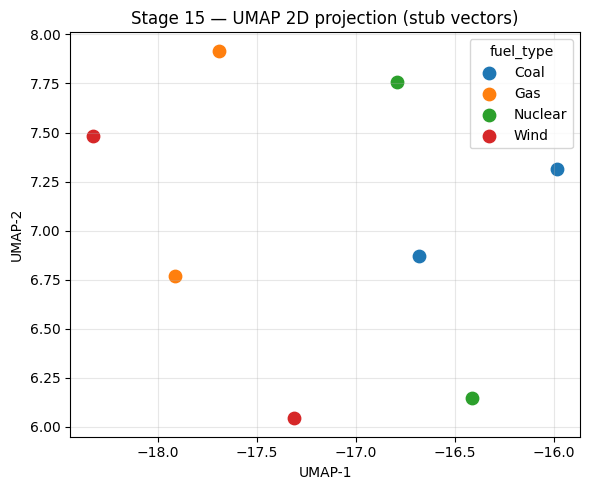

In [5]:
# T5 Cell 5 — UMAP 2D projection coloured by fuel_type.
import matplotlib.pyplot as plt

from bristol_ml.embeddings._projection import project_to_2d

# UMAP requires n_neighbors < n_samples; the tiny fixture has 8 rows
# so we cap n_neighbors at min(15, n_samples - 1) (UMAP's own
# default-clamp).  This keeps the cell deterministic and warning-free
# at fixture size while still using the documented defaults at
# normal corpus sizes.
n_samples = cache.vectors.shape[0]
n_neighbors_eff = max(2, min(15, n_samples - 1))

coords_2d = project_to_2d(
    cache.vectors,
    random_state=42,
    n_neighbors=n_neighbors_eff,
)
print(f"projected shape: {coords_2d.shape}")

# Map row order back to corpus ordering so the colour key matches.
fuel = corpus["fuel_type"].astype(str).fillna("None")
fig, ax = plt.subplots(figsize=(6, 5), dpi=100)
for fuel_value, group in fuel.groupby(fuel):
    idx = group.index.to_list()
    ax.scatter(
        coords_2d[idx, 0],
        coords_2d[idx, 1],
        label=fuel_value,
        s=80,
    )
ax.set_title("Stage 15 — UMAP 2D projection (stub vectors)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(title="fuel_type", loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# T5 Cell 6 — Optional Stage 14 cross-stage join (skip-clean if absent).
# Plan A5: if a Stage 14 extracted-features parquet is on disk at the
# documented path, merge structured fields (event_type, fuel_type,
# affected_capacity_mw, confidence) onto the top-k result.  If absent,
# print a single-line banner and continue.  Either branch must execute
# cleanly under CI's default stub-mode codepath.

STAGE_14_OUT = REPO_ROOT / "data" / "features" / "remit_extracted.parquet"

if STAGE_14_OUT.exists():
    extracted = pd.read_parquet(STAGE_14_OUT)
    # The Stage 14 extractor keys on (mrid, revision_number); rebuild
    # the same row_id so the merge is a single-key join.
    extracted = extracted.assign(
        row_id=extracted["mrid"].astype(str) + "::" + extracted["revision_number"].astype(str)
    )
    join_cols = ["row_id", "event_type", "fuel_type", "affected_capacity_mw", "confidence"]
    available = [c for c in join_cols if c in extracted.columns]
    enriched = neighbours_df.merge(
        extracted[available],
        on="row_id",
        how="left",
        suffixes=("", "_stage14"),
    )
    print(f"Stage 14 output found at {STAGE_14_OUT} ({len(extracted)} rows).")
    print()
    print(enriched.to_string(index=False, max_colwidth=40))
else:
    print(f"Stage 14 output not found at {STAGE_14_OUT} — skipping cross-stage join.")

Stage 14 output not found at /workspace/data/features/remit_extracted.parquet — skipping cross-stage join.


## Why a content-hash cache?

Intent line 32: *"the index's interface is small enough that swapping
the vector store implementation later is a mechanical change"*. The
load-bearing mechanic is that the cache **invalidates on either**:

- the corpus SHA-256 changes (a row was added / removed / edited),
- **or** the model_id changes (we swapped from stub to gte-modernbert).

The provenance fields (`corpus_sha256`, `model_id`, `embedded_at_utc`)
travel inside the parquet's `custom_metadata`, so a reader can audit
"which model produced these vectors" without re-running the embed.

## What's next

- A future RAG-style stage will consume the `Embedder` + `VectorIndex`
  Protocol pair to retrieve REMIT context for free-form questions.
- Stage 16 (model-with-REMIT) may optionally consume nearest-neighbour
  features as model input alongside the Stage 14 structured-extracted
  fields.  The `as_of` mechanic from Stage 13 is what guarantees the
  join uses only information available at training time, no leakage.
